In [1]:
!pip install torch torchvision torchaudio lightning pytorch-forecasting pandas numpy tensorboard optuna tensorboardx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 52.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [3]:
def remove_unwanted_columns(df):
    """
    Removes specific unwanted columns if they exist in the DataFrame.
    """
    unwanted = [
        'Unnamed: 0', 'Month', 'day_of_week',
        'Day_of_week', 'pm25_lag1', 'pm25_lag7', 'to_date',
    ]

    # Only drop columns that are actually present in the dataframe
    cols_to_drop = [col for col in unwanted if col in df.columns]

    return df.drop(columns=cols_to_drop)



def fix_temporal_structure(df, datetime_col='from_date', freq='h'):
    """
    Ensures the dataframe has a continuous datetime index with no gaps.
    """
    df[datetime_col] = pd.to_datetime(df[datetime_col])

    # Remove duplicates by taking the mean of entries with the same timestamp
    df = df.groupby(datetime_col).mean(numeric_only=True).reset_index()

    # Set index and fill missing hours
    df = df.set_index(datetime_col)
    df = df.asfreq(freq)

    return df



def apply_physical_bounds(df):
    """
    Clips sensor data to realistic physical limits.
    """
    # Pollutants & Wind Speed: Cannot be negative
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].clip(lower=0)

    # Humidity: Cannot exceed 100%
    if 'humidity' in df.columns:
        df['humidity'] = df['humidity'].clip(upper=100)

    return df



def handle_missing_values(df, max_gap=3):
    """
    Fills gaps using linear interpolation.
    'max_gap' limits interpolation so we don't 'guess' too much data.
    """
    # Interpolate small gaps linearly
    df = df.interpolate(method='linear', limit=max_gap)

    # For larger gaps, use a backfill/forward fill to catch edges
    df = df.ffill().bfill()

    return df

In [4]:
def load_and_preprocess_split(train_path, val_path, test_path):
    """
    Loads three CSVs, cleans them using the predefined pipeline,
    and returns scaled DataFrames + the fitted scaler.
    """

    # 1. Load raw data
    datasets = {
        'train': pd.read_csv(train_path),
        'val': pd.read_csv(val_path),
        'test': pd.read_csv(test_path)
    }

    processed_dfs = {}

    for name, df in datasets.items():
        # Apply the pipeline we built earlier
        # Note: 'city' and 'to_date' are usually dropped for modeling
        df_clean = (df.pipe(remove_unwanted_columns)  # 1. Strip junk first
                      .pipe(fix_temporal_structure)    # 2. Fix time index
                      .pipe(apply_physical_bounds)    # 3. Clip sensor errors
                      .pipe(handle_missing_values))    # 4. Fill NaNs

        if 'time_idx' in df_clean.columns:
            df_clean['time_idx'] = df_clean['time_idx'].astype(int)
        processed_dfs[name] = df_clean

    # 2. Feature Scaling (Standardization)
    # We fit ONLY on train to prevent data leakage

    return processed_dfs['train'], processed_dfs['val'], processed_dfs['test']

In [5]:
train_file = "Train_data.csv"
val_file = "Validation_data.csv"
test_file = "Test_data.csv"

In [6]:
train_data, val_data, test_data = load_and_preprocess_split(train_file, val_file, test_file)

In [7]:
train_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2017-01-01 00:00:00,212.535000,326.436250,54.380909,82.325000,51.679091,99.992000,16.894,2.032500,20.7800,791.506,0.565000,12.128,85.467143,0.0,1
2017-01-01 01:00:00,221.626667,349.794286,57.869000,81.743333,50.840000,104.844444,15.530,2.308571,20.2050,791.420,0.595000,11.600,86.110000,0.0,2
2017-01-01 02:00:00,217.650000,336.096250,42.166364,71.381667,43.699091,78.736000,13.922,1.623750,46.0625,791.380,0.498333,11.336,86.748571,0.0,3
2017-01-01 03:00:00,226.055000,307.732500,41.658182,70.268333,38.291818,72.843000,13.780,1.568571,27.9700,791.540,0.531667,10.564,86.732857,0.0,4
2017-01-01 04:00:00,219.325556,277.064286,56.181000,61.455000,34.336000,92.034444,15.322,1.868333,16.5950,791.634,0.386667,9.900,87.377143,0.0,5


In [8]:
train_data.columns

Index(['pm25', 'pm10', 'no', 'nh3', 'no2', 'nox', 'so2', 'co', 'ozone', 'bp',
       'wind_speed', 'air_temp', 'humidity', 'rainfall', 'time_idx'],
      dtype='object')

In [9]:
feature_cols=[ 'pm25', 'pm10', 'no', 'nh3', 'no2', 'nox', 'so2', 'co', 'ozone', 'bp',
       'wind_speed', 'air_temp', 'humidity', 'rainfall']
scaler = MinMaxScaler()
scaler.fit(train_data[feature_cols])
train_data[feature_cols] = scaler.transform(train_data[feature_cols])
val_data[feature_cols] = scaler.transform(val_data[feature_cols])
test_data[feature_cols] = scaler.transform(test_data[feature_cols])

In [10]:
train_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0,1
2017-01-01 01:00:00,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0,2


In [11]:
val_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2023-01-01 00:00:00,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0,52585
2023-01-01 01:00:00,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0,52586


In [12]:
test_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2023-03-01 00:00:00,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.02508,0.347751,0.559211,0.0,54001
2023-03-01 01:00:00,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.02163,0.351402,0.534649,0.0,54002


In [13]:
train_data = train_data.reset_index(drop=True)
train_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
0,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0,1
1,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0,2
2,0.254003,0.330607,0.122315,0.267693,0.188049,0.195340,0.169915,0.128538,0.280472,0.207668,0.013831,0.163223,0.887574,0.0,3
3,0.263951,0.302009,0.120730,0.263246,0.157676,0.178996,0.168180,0.124170,0.165346,0.208238,0.015098,0.145396,0.887407,0.0,4
4,0.255986,0.271087,0.166050,0.228039,0.135456,0.232222,0.187014,0.147899,0.092966,0.208573,0.009589,0.130063,0.894238,0.0,5


In [14]:
test_data = test_data.reset_index(drop=True)
test_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
0,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.025080,0.347751,0.559211,0.0,54001
1,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.021630,0.351402,0.534649,0.0,54002
2,0.086687,0.222010,0.194948,0.182882,0.160864,0.213559,0.127595,0.103226,0.032776,0.846069,0.021645,0.341923,0.551080,0.0,54003
3,0.081731,0.206593,0.196309,0.171079,0.178890,0.210963,0.109311,0.093880,0.038824,0.845452,0.026326,0.344133,0.552164,0.0,54004
4,0.079842,0.202226,0.181656,0.168230,0.149773,0.211327,0.097874,0.080843,0.042704,0.845457,0.026797,0.342198,0.544343,0.0,54005


In [15]:
val_data = val_data.reset_index(drop=True)
val_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
0,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0,52585
1,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0,52586
2,0.165000,0.193064,0.110916,0.200291,0.118967,0.129111,0.083353,0.088879,0.031809,0.881702,0.012433,0.167241,0.886555,0.0,52587
3,0.160067,0.185576,0.124561,0.191399,0.115773,0.137774,0.083461,0.089987,0.030547,0.880580,0.011337,0.160481,0.892008,0.0,52588
4,0.149380,0.170272,0.131735,0.187531,0.112380,0.145666,0.068054,0.085447,0.034143,0.880563,0.012740,0.156671,0.895083,0.0,52589


In [16]:
train_data["city"] = "Delhi"
train_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx,city
0,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0,1,Delhi
1,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0,2,Delhi
2,0.254003,0.330607,0.122315,0.267693,0.188049,0.195340,0.169915,0.128538,0.280472,0.207668,0.013831,0.163223,0.887574,0.0,3,Delhi
3,0.263951,0.302009,0.120730,0.263246,0.157676,0.178996,0.168180,0.124170,0.165346,0.208238,0.015098,0.145396,0.887407,0.0,4,Delhi
4,0.255986,0.271087,0.166050,0.228039,0.135456,0.232222,0.187014,0.147899,0.092966,0.208573,0.009589,0.130063,0.894238,0.0,5,Delhi


In [17]:
test_data["city"] = "Delhi"
test_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx,city
0,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.025080,0.347751,0.559211,0.0,54001,Delhi
1,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.021630,0.351402,0.534649,0.0,54002,Delhi
2,0.086687,0.222010,0.194948,0.182882,0.160864,0.213559,0.127595,0.103226,0.032776,0.846069,0.021645,0.341923,0.551080,0.0,54003,Delhi
3,0.081731,0.206593,0.196309,0.171079,0.178890,0.210963,0.109311,0.093880,0.038824,0.845452,0.026326,0.344133,0.552164,0.0,54004,Delhi
4,0.079842,0.202226,0.181656,0.168230,0.149773,0.211327,0.097874,0.080843,0.042704,0.845457,0.026797,0.342198,0.544343,0.0,54005,Delhi


In [18]:
val_data["city"] = "Delhi"
val_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx,city
0,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0,52585,Delhi
1,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0,52586,Delhi
2,0.165000,0.193064,0.110916,0.200291,0.118967,0.129111,0.083353,0.088879,0.031809,0.881702,0.012433,0.167241,0.886555,0.0,52587,Delhi
3,0.160067,0.185576,0.124561,0.191399,0.115773,0.137774,0.083461,0.089987,0.030547,0.880580,0.011337,0.160481,0.892008,0.0,52588,Delhi
4,0.149380,0.170272,0.131735,0.187531,0.112380,0.145666,0.068054,0.085447,0.034143,0.880563,0.012740,0.156671,0.895083,0.0,52589,Delhi


### Check if data is correct

In [19]:
import numpy as np

expected = np.arange(train_data["time_idx"].iloc[0], train_data["time_idx"].iloc[0] + len(train_data))
(train_data["time_idx"].values == expected).all()

np.True_

In [20]:
last_train_idx = train_data["time_idx"].iloc[-1]
print("Last train time_idx:", last_train_idx)

Last train time_idx: 52584


In [21]:
expected_start = last_train_idx + 1
expected_end = last_train_idx + len(val_data)
expected = np.arange(expected_start, expected_end + 1)  # inclusive
(val_data["time_idx"].values == expected).all()

np.True_

In [22]:
last_val_idx = val_data["time_idx"].iloc[-1]
print("Last val time_idx:", last_val_idx)

Last val time_idx: 54000


In [23]:
expected_start = last_val_idx + 1
expected_end = last_val_idx + len(test_data)
expected = np.arange(expected_start, expected_end + 1)  # inclusive
(test_data["time_idx"].values == expected).all()

np.True_

In [24]:
import copy
from pathlib import Path
import warnings

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import MultiNormalizer, GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)
from pytorch_forecasting import Baseline
from pytorch_forecasting.metrics import MAE, RMSE
from lightning.pytorch.callbacks import TQDMProgressBar

In [25]:
from pytorch_forecasting.data.encoders import TorchNormalizer

In [26]:
max_prediction_length = 24
max_encoder_length = 168

training = TimeSeriesDataSet(
    train_data,
    time_idx="time_idx",
    target="pm25",
    group_ids=["city"],
    min_encoder_length=24,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["city"],
    static_reals=[],
    time_varying_known_categoricals=[],
    variable_groups={},
    time_varying_known_reals=[
        "time_idx", "wind_speed", "air_temp", "humidity", "bp", "rainfall",
    ],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[
        "pm10", "pm25", "no", "nh3", "no2", "so2", "co", "ozone", "nox",
    ],
    # identity normalizer because we already scaled with MinMaxScaler
    target_normalizer=TorchNormalizer(method="identity", center=False),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

In [27]:
history_for_val = train_data.iloc[-max_encoder_length:]
val_combined = pd.concat([history_for_val, val_data]).reset_index(drop=True)

validation = TimeSeriesDataSet.from_dataset(
    training,
    val_combined,
    predict=False,
    stop_randomization=True
)

In [28]:
train_dataloader = training.to_dataloader(
    train=True, batch_size=128, num_workers=1
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=64, num_workers=1
)

In [29]:
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint


In [30]:
from pytorch_forecasting.metrics import QuantileLoss

In [31]:
class LossHistory(pl.Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses   = []

    def on_train_epoch_end(self, trainer, pl_module):
        # TFT logs "train_loss_epoch" after aggregation; fall back to "train_loss"
        loss = trainer.callback_metrics.get("train_loss_epoch") or \
               trainer.callback_metrics.get("train_loss")
        if loss is not None:
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())


In [32]:
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=5, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()
tqdm_logger = TQDMProgressBar(refresh_rate =20)
logger = TensorBoardLogger("lightning_logs_pm25_7days")
loss_history= LossHistory()


checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints-pm25-7days",
    filename="tft-{epoch:02d}-{val_loss:.4f}",
    monitor="val_loss",
    save_top_k=3,        # keep best 3 models
    mode="min",
    save_last=True       # also save last epoch
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="gpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback, tqdm_logger, checkpoint_callback, loss_history],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    output_size=1,
    hidden_continuous_size=32,
    loss=RMSE(),
    log_interval=10,
    optimizer="adamw",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 394.3k


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [33]:
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ RMSE                            │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.2 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 20.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  117 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 49.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     65 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 394 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 394 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 549                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [34]:
history = val_data.iloc[-max_encoder_length:].copy()
step_size   = max_prediction_length
total_steps = len(test_data)
targets     = ["pm25"]

all_preds   = []
all_actuals = []

target_idx = feature_cols.index("pm25")

for start_idx in range(0, total_steps, step_size):
    true_chunk = test_data.iloc[start_idx:start_idx + step_size]
    if len(true_chunk) == 0:
        break

    encoder_df = history.iloc[-max_encoder_length:].copy()
    window_df  = pd.concat([encoder_df, true_chunk]).reset_index(drop=True)

    global_time_offset        = int(encoder_df["time_idx"].iloc[0])
    window_df["time_idx"]     = range(global_time_offset, global_time_offset + len(window_df))
    window_df["time_idx"]     = window_df["time_idx"].astype(int)

    window_dataset = TimeSeriesDataSet.from_dataset(
        training,
        window_df,
        predict=True,
        stop_randomization=True
    )
    window_dataloader = window_dataset.to_dataloader(
        train=False, batch_size=64, num_workers=1
    )

    preds = tft.predict(
        window_dataloader,
        mode="prediction",
        trainer_kwargs=dict(accelerator="gpu")
    )

    chunk_len  = len(true_chunk)

    pred_chunk = preds.reshape(-1).cpu().numpy()[:chunk_len]   # (chunk_len,)

    # ── Inverse transform predictions ──
    dummy_pred = np.zeros((len(pred_chunk), len(feature_cols)))
    dummy_pred[:, target_idx] = pred_chunk
    pred_original = scaler.inverse_transform(dummy_pred)[:, target_idx]  # (chunk_len,)

    # ── Inverse transform actuals ──
    actual_chunk = true_chunk["pm25"].values                   # scaled [0,1]
    dummy_act    = np.zeros((chunk_len, len(feature_cols)))
    dummy_act[:, target_idx] = actual_chunk
    act_original = scaler.inverse_transform(dummy_act)[:, target_idx]    # (chunk_len,)

    all_preds.append(pred_original)
    all_actuals.append(act_original)

    # Update history with true observed values
    history = pd.concat([history, true_chunk])


all_preds   = np.concatenate(all_preds)
all_actuals = np.concatenate(all_actuals)


print(f"n_points : {len(all_preds)}")
print(f"pred  range: {all_preds.min():.2f} – {all_preds.max():.2f}")
print(f"actual range: {all_actuals.min():.2f} – {all_actuals.max():.2f}")


from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae  = mean_absolute_error(all_actuals, all_preds)

print(f"\n── Metrics over full 30-day test set (720 points) ──")
print(f"PM2.5  RMSE: {rmse:.4f} µg/m³  |  MAE: {mae:.4f} µg/m³")



INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-pac

n_points : 744
pred  range: 30.66 – 154.37
actual range: 14.50 – 195.29

── Metrics over full 30-day test set (720 points) ──
PM2.5  RMSE: 19.8706 µg/m³  |  MAE: 15.2358 µg/m³


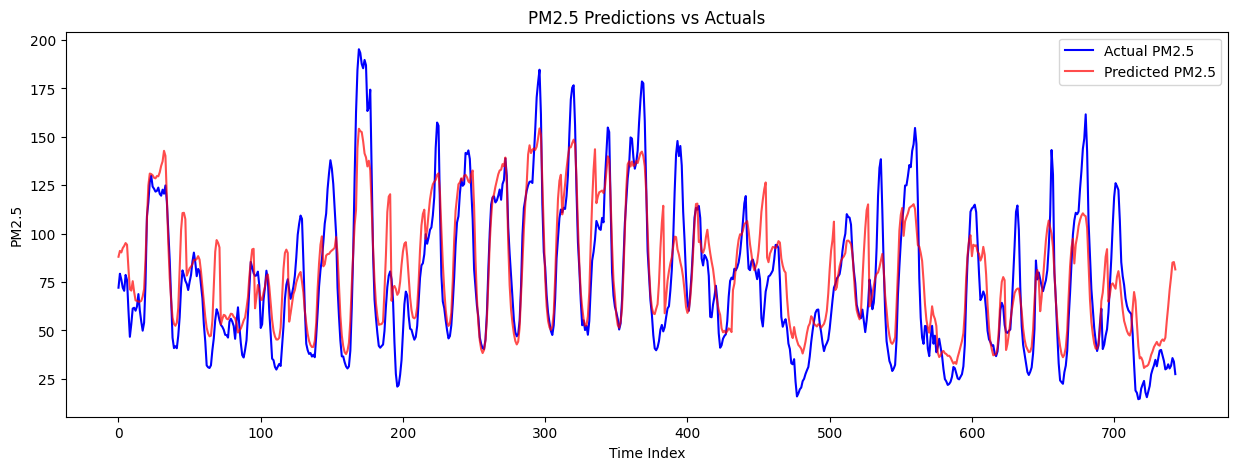

In [35]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15,5))
plt.plot(all_actuals, label="Actual PM2.5", color="blue")
plt.plot(all_preds, label="Predicted PM2.5", color="red", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("PM2.5")
plt.title("PM2.5 Predictions vs Actuals")
plt.legend()
plt.show()

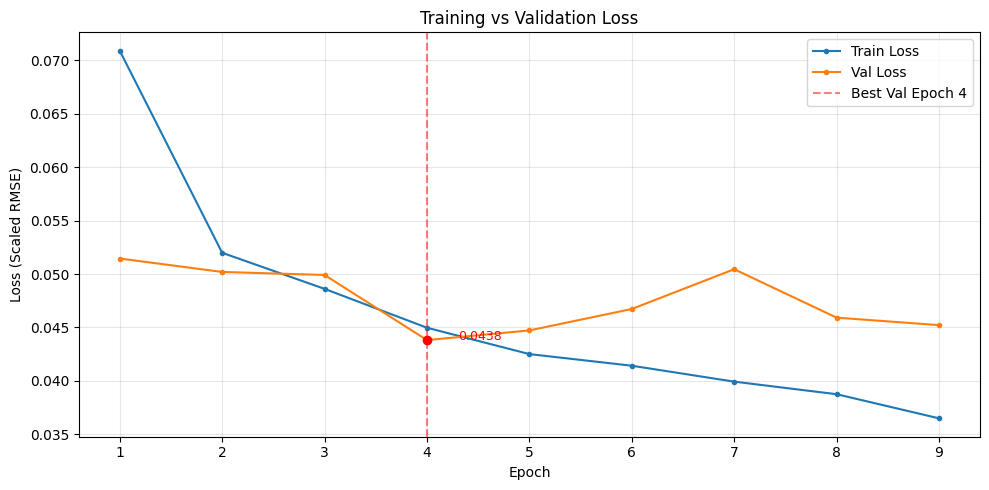

In [36]:
import matplotlib.pyplot as plt

def plot_loss_history(loss_history):
    train_losses = loss_history.train_losses
    val_losses   = loss_history.val_losses

    # Align lengths in case val runs one epoch behind
    min_len = min(len(train_losses), len(val_losses))
    train_losses = train_losses[:min_len]
    val_losses   = val_losses[:min_len]

    epochs = range(1, min_len + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker="o", markersize=3)
    plt.plot(epochs, val_losses,   label="Val Loss",   marker="o", markersize=3)

    # Mark best val loss
    best_epoch = val_losses.index(min(val_losses)) + 1
    best_val   = min(val_losses)
    plt.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.5, label=f"Best Val Epoch {best_epoch}")
    plt.scatter([best_epoch], [best_val], color="red", zorder=5)
    plt.annotate(f"{best_val:.4f}", xy=(best_epoch, best_val),
                 xytext=(best_epoch + 0.3, best_val), fontsize=9, color="red")

    plt.xlabel("Epoch")
    plt.ylabel("Loss (Scaled RMSE)")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("loss_curve.png", dpi=150)
    plt.show()

plot_loss_history(loss_history)

In [39]:
history = val_data.iloc[-max_encoder_length:].copy()
step_size   = max_prediction_length
total_steps = len(test_data)
targets     = ["pm25"]

all_preds   = []
all_actuals = []

target_idx = feature_cols.index("pm25")

for start_idx in range(0, total_steps, step_size):
    true_chunk = test_data.iloc[start_idx:start_idx + step_size]
    if len(true_chunk) == 0:
        break

    encoder_df = history.iloc[-max_encoder_length:].copy()
    window_df  = pd.concat([encoder_df, true_chunk]).reset_index(drop=True)

    global_time_offset        = int(encoder_df["time_idx"].iloc[0])
    window_df["time_idx"]     = range(global_time_offset, global_time_offset + len(window_df))
    window_df["time_idx"]     = window_df["time_idx"].astype(int)

    window_dataset = TimeSeriesDataSet.from_dataset(
        training,
        window_df,
        predict=True,
        stop_randomization=True
    )
    window_dataloader = window_dataset.to_dataloader(
        train=False, batch_size=64, num_workers=1
    )

    best_model = tft.load_from_checkpoint(
    "/content/checkpoints-pm25-7days/last.ckpt")
    best_model.eval()
    preds = best_model.predict(
        window_dataloader,
        mode="prediction",
        trainer_kwargs=dict(accelerator="gpu")
    )

    chunk_len  = len(true_chunk)

    pred_chunk = preds.reshape(-1).cpu().numpy()[:chunk_len]   # (chunk_len,)

    # ── Inverse transform predictions ──
    dummy_pred = np.zeros((len(pred_chunk), len(feature_cols)))
    dummy_pred[:, target_idx] = pred_chunk
    pred_original = scaler.inverse_transform(dummy_pred)[:, target_idx]  # (chunk_len,)

    # ── Inverse transform actuals ──
    actual_chunk = true_chunk["pm25"].values                   # scaled [0,1]
    dummy_act    = np.zeros((chunk_len, len(feature_cols)))
    dummy_act[:, target_idx] = actual_chunk
    act_original = scaler.inverse_transform(dummy_act)[:, target_idx]    # (chunk_len,)

    all_preds.append(pred_original)
    all_actuals.append(act_original)

    # Update history with true observed values
    history = pd.concat([history, true_chunk])


all_preds   = np.concatenate(all_preds)
all_actuals = np.concatenate(all_actuals)


print(f"n_points : {len(all_preds)}")
print(f"pred  range: {all_preds.min():.2f} – {all_preds.max():.2f}")
print(f"actual range: {all_actuals.min():.2f} – {all_actuals.max():.2f}")


from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae  = mean_absolute_error(all_actuals, all_preds)

print(f"\n── Metrics over full 30-day test set (720 points) ──")
print(f"PM2.5  RMSE: {rmse:.4f} µg/m³  |  MAE: {mae:.4f} µg/m³")



/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does

n_points : 744
pred  range: 30.66 – 154.37
actual range: 14.50 – 195.29

── Metrics over full 30-day test set (720 points) ──
PM2.5  RMSE: 19.8706 µg/m³  |  MAE: 15.2358 µg/m³


# Method 2: Predict NO2